In [22]:
# Import necessary Libraries
import scipy
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import numpy as np

In [23]:
# a) Define variables used in V:
phi = var(r'φ') # scalar field
k = 1 # Mpl^-2
V0 = var(r'V_0')
alp = var(r'α')
M = var('M')
N = var('N')
beta = var('β') # coupling variable
alp = 4 

In [24]:
# Expression for V and dv/dphi
def V(M,phi):
    return (M^(4+alp))/phi^alp

def dVdphi(M,phi):
    return -alp*V(M,phi)/phi

In [25]:
show(V(M,phi)) # Test of V

M^8/φ^4

In [48]:
# Cosmological constants
h = 0.7
ohm_m = 0.31
Ho = 2.1332e-42*h*4.10677e-19 # Hubble constant in reduced plank mass units
rho_c0 = (3*Ho**2/(k**2)) # current critical energy density
A = 0.65
M_val = ((rho_c0*(8*pi)^(alp/2))^(1/(alp+4)))*A
gam = 1
beta = 0
Ni = 0
show(M_val)

(1.10977135095917e-15)*pi^(1/4)

The aim of the`CoupledSteinhardt(X,N)` function is to output our primed Klein Gordon Equation as two first order differential equations for $φ'$ and $φ''$ in terms of X where `X[0]` = φ and `X[1]` = φ' for a value of $N$. We obtain outputs for $φ'$ and $φ''$ by:
1. Calculating the scale factor $a$ using $a = \exp{N}$
2. Generating $ρ_m$ using $ρ_m = ρ_{c,0}Ω_m(aa_i)^{-3}$
3. Generating $V$ and $\frac{dV}{dφ}$ using `X[0]`
4. Calculating $H^2$ and $\frac{\dot{H}}{H^2}$ using previous parameters and `X[1]`
5. Pulling everything together

In [49]:
# Klein Gordon Equation Written as two first order differential equations in X
def CoupledSteinhardt(X,N):
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    
    Vfunc = V(M_val,X[0])
    dVfunc = dVdphi(M_val,X[0])

    H2 = (rho_m + Vfunc)/(3-0.5*(X[1])^2)
    HdotH2 = -0.5*((X[1])^2+ gam*rho_m/H2)
    x1prime = X[1]
    x2prime = -(3+HdotH2)*X[1] - dVfunc/H2- beta*rho_m/H2
    return [x1prime,x2prime]

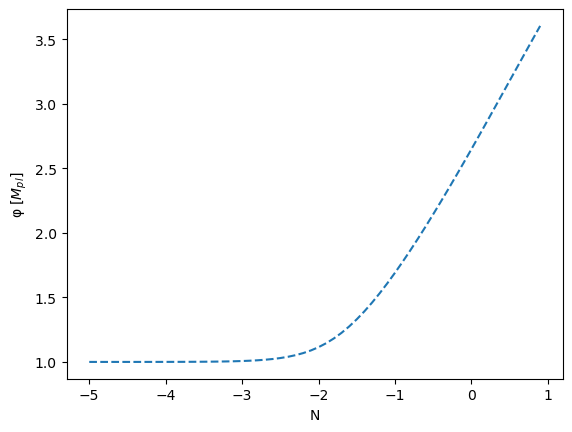

In [50]:
# Test to make sure odeint integrates CoupledSteinhardt correctly:
# Set φ = 1 and φ' = 0 in this test

# Also set range of N
Nrange = np.arange(-5,1,.1) # N values
z_values = exp(-Nrange) # z+1 = exp(-N)
Ni = 0

'''
Use scipy odeint to numerically integrate Klein Gordon for a scalar field where φ_i = 1 and φ'_i = 0
'''
sol = odeint(CoupledSteinhardt,[1,0],t=Nrange)
phi_sol = sol[:,0] # φ solutions
phi_prime = sol[:,1] # φ' solutions

# Visualise solutions
plt.xlabel("N")
plt.ylabel(r"φ $[M_{pl}]$")
plt.plot(Nrange,phi_sol,'--')

In [51]:
# Function to determine other cosmological parameters using numerical values of φ and φ'
def other_parameters(fi,dfi,N):
    '''
    Function that determines other cosmological parameters using
    fi = φ
    dfi = φ'
    N => N = ln(a)
    See supporting key file for information on parameters calculated
    '''
    a = exp(N) # N = ln(a)
    ai = exp(Ni)
    z = exp(-N)-1
    rho_m = rho_c0*ohm_m*(a*ai)^(-3)
    Pot = V(M_val,fi)
    H2 = (rho_m + Pot)/(3-1/2*dfi^2)
    rho_φ = 0.5*(dfi^2*H2) + Pot # Energy density of φ (ρ_φ)
    #ratio_rho = rho_φ/rho_m
    
    O_φ = ((k^2)/3)*(rho_φ/H2) # Ωφ
    O_m = 1-O_φ
    #ratio_O = O_φ/O_m
    
    Pφ = 0.5*(dfi^2*H2) - Pot
    Y_φ = (Pφ+rho_φ)/rho_φ
    w = Pφ/rho_φ # Equation of State wΦ
    weff = Pφ/(rho_φ +rho_m)
    return z,rho_φ,Pφ,O_φ,O_m,w,Y_φ,rho_m,weff

In [52]:
# Now using numerical solutions for φ and φ' for a scalar field where φ_i = 1 and φ'_i = 0 that was generated previously
z,rho_s,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(phi_sol,phi_prime,Nrange)

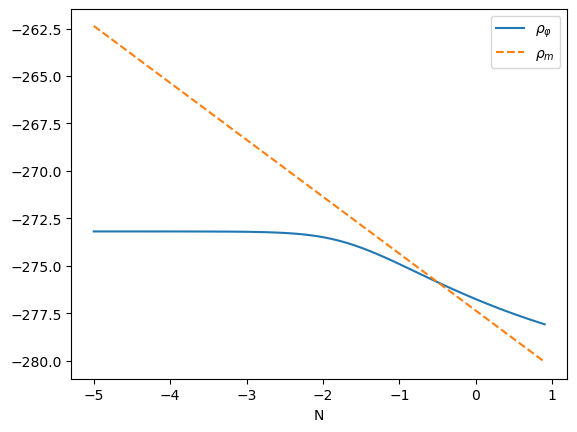

In [53]:
# Plots of cosmological parameters vs N  - add or remove # to view plots

#plt.plot(Nrange,phi_sol, label  =r"φ")
#plt.plot(Nrange,phi_prime, label  =r"φ'")
plt.plot(Nrange,log(rho_s),label=r"$ρ_φ$")
plt.plot(Nrange,log(rho_m),label=r"$ρ_m$",ls='--')
#plt.plot(Nrange,P,label=r"P_φ") 
#plt.plot(Nrange,O_Q,label=r"Ω_φ") 
#plt.plot(Nrange,w,label=r"ω") 
plt.xlabel("N")
#plt.xlim([-1,1])
plt.legend()
#plt.savefig(r"log of $ρ_φ$ and $ρ_m$ for Q = {}.png".format(np.round(Q,3))) 

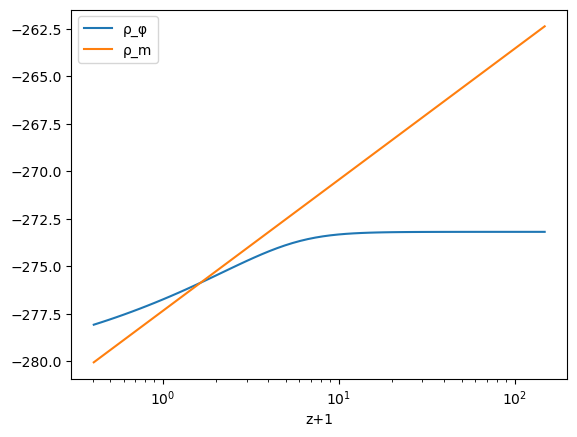

In [54]:
# Plots of cosmological parameters vs z+1  - add or remove # to view plots
Z = z+1
#plt.plot(Z,phi_sol, label  =r"φ")
#plt.plot(Z,phi_prime, label  =r"φ'")
plt.plot(Z,log(rho_s),label=r"ρ_φ")
plt.plot(Z,log(rho_m),label=r"ρ_m")
#show(Y_Q)
#plt.plot(Z,(Y_Q),label=r"γ_φ")
#plt.plot(Z,ratio_O,label = r"ratio_Ω")
#plt.plot(Z,P,label=r"P_φ")
#show(max(O_Q))
#show(max(Y_Q))
#plt.plot(Z,log(O_Q),label=r"Ω_φ") 
#plt.plot(Z,log(O_m),label=r"Ω_m")
#plt.plot(Z,O_m/O_Q,label=r"ratio_Ω")
#plt.plot(Z,w,label=r"ω") 
plt.xlabel("z+1")
plt.xscale('log')
plt.legend()

# Evolution of 6 cosmological parameters for different φ_i
In the following cell we simulate the evolution of cosmological parameters over a chosen range of $N$ while changing the strength of the coupling $\beta$. We then plot the evolution of the parameters as one figure. We only show the evolution of 6 cosmological parameters and these are: the scalar field, $\phi$, the potential of the scalar field, $V(\phi)$, the effective equation of state of the field, $\omega_f$, the energy densities of the scalar field and matter ($\rho_φ$,$\rho_m$) in logarithmic scales and the fractional densities of the scalar field and matter ($\Omega_φ$, $\Omega_m$). 

Using the results from our study on normal quintessence, we choose  $φ_i = 0.9$ and  $φ_i ' = 0$. The numerical solutions of the cosmological parameters are generated inside the for loop using odeint as we did above but with different levels of coupling including no coupling. Once we have generated this data for the set range of N, we substitute φ and φ' into the other_parameters function to produce the remaining cosmological parameters. We do this for all values of $\beta$  to observe how the coupling influences the evolution of the cosmological parameters. For each $\beta$ value, each parameter is then assigned to a subplot using the function xaxis as we did for normal quintessence. 

The xaxis function takes four inputs: x, label, i, ls. x is the x-axis and so must be either Nrange or Z, where Z = z+1 and in logarithmic scales. label is where you enter the label for the x_axis. i is the same i that is in the for loop so are our values of $\beta$. ls is the linestyle of the plots. This is needed so that each coupling solution a different linestyle. 

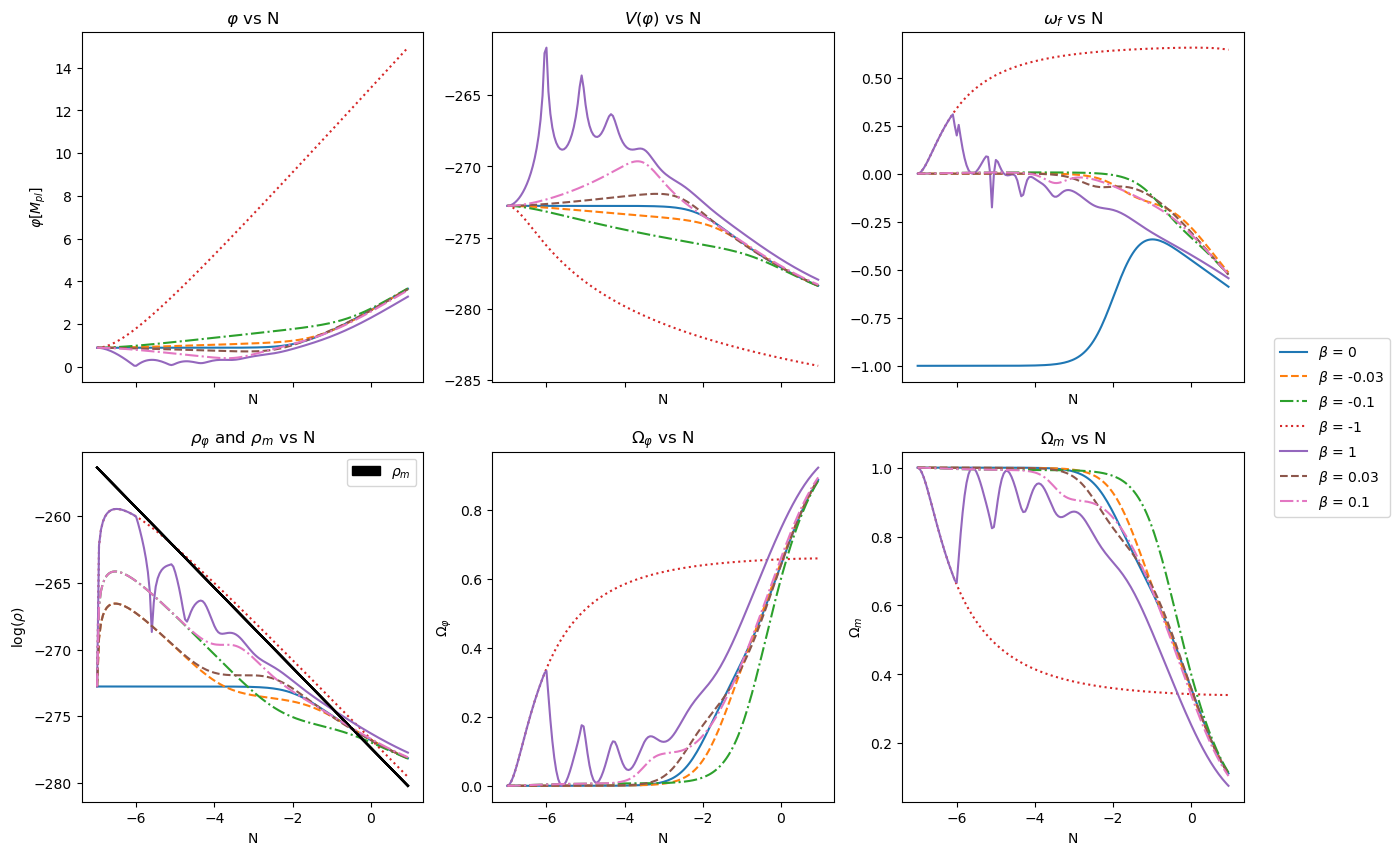

In [58]:
Nrange = np.arange(-7,1,.05)
Q_list = []
Ni = Nrange[0]
w_list = []
from itertools import cycle
StyleList = ['solid','dashed','dashdot','dotted']
cmap = ['red','blue','green']
lines = cycle(StyleList)
colours = cycle(cmap)

fig, axs = plt.subplots(2,3, figsize=(15, 10),sharex=True)
def xaxis(x,label,i,ls):
    
    #axs[0,0].set_yscale('log')
    axs[0,0].plot(x,solQ[:,0],label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[0,0].set(ylabel = r"$φ[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$ vs {}".format(label))
    
    #axs[0,1].plot(x,solQ[:,1],label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,1].set(ylabel = r"$φ$'$[M_{pl}]$", xlabel = "{}".format(label),title=r"$φ$' vs {}".format(label))

    axs[0,1].plot(x,log(potentials),label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    axs[0,1].set(xlabel = "{}".format(label),title=r"$V(φ)$ vs {}".format(label))
    
    axs[1,0].plot(x,log(rho),label=r"rho", linestyle = "{}".format(ls))
    axs[1,0].plot(x,log(rho_m),label=r"rho_m",linestyle = "solid", color = "black")
    axs[1,0].set(ylabel = r"log($ρ$)", xlabel = "{}".format(label),title=r"$ρ_φ$ and $ρ_m$ vs {}".format(label))
    #axs[1,0].set_xlim(-6.95,0.99)
    
    axs[1,1].plot(x,O_Q,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,1].set(ylabel = r"$Ω_φ$", xlabel = "{}".format(label),title=r"$Ω_φ$ vs {}".format(label))
    #axs[1,1].set_xlim(-9,5)
    #axs[1,1].legend()
    
    axs[1,2].plot(x,O_m,label=r"$φ_i$ = {}".format(i),linestyle = "{}".format(ls))
    axs[1,2].set(ylabel = r"$Ω_m$", xlabel = "{}".format(label),title=r"$Ω_m$ vs {}".format(label))
    #axs[1,2].legend()

    if i == 0:
        '''
        This checks to see whether β is zero or not. If it zero, we show ω rather than ωf. 
        '''
        axs[0,2].plot(x,w,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        #axs[0,2].set( xlabel = "{}".format(label),title=r"ω vs {}".format(label))
    else:
        axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
        axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))
        
    #axs[0,2].legend()
    #axs[0,2].plot(x,weff,label=r"$φ_i$= {}".format(i),linestyle = "{}".format(ls))
    #axs[0,2].set( xlabel = "{}".format(label),title=r"$ω_f$ vs {}".format(label))

    if label == "z+1":
        axs[0,0].set_xscale('log')
        axs[0,0].xaxis.set_inverted(True)
        secax0 = axs[0,0].twiny()
        secax0.set_xlim(Nrange[0],Nrange[-1])
        secax0.set_xlabel('N')

# Here is where I would change which coupling constants, beta (previously Q hence the names) i would simulate for 

#Q_values = -np.arange(0,1,.1) # 
Q_values = [0,-0.03,-0.1,-1,1,0.03,0.1]
#Q_values = [0,-0.03]
#Q_values = [-1,-0.1,-0.03,0,0.03,0.1,1]
#Q_values = [0]

for i in Q_values:
    Ni = Nrange[0]
    Ni=0
    beta = i
    Q_list.append(r"$\beta$ = {}".format(np.round(i,4)))
    solQ = odeint(CoupledSteinhardt,[.9,0],t=Nrange) # Here we have chosen a specific value for $φ_i due to previously results
    potentials = (V(M_val,solQ[:,0]))
    '''When I generate solutions, I also find the corresponding z,ωφ,ρφ,Ωφ,Pφ values for all initial Q values ranged. '''
    z,rho,P,O_Q,O_m,w,Y_Q,rho_m,weff = other_parameters(solQ[:,0],solQ[:,1],Nrange)
    w_list.append((i,round(max(w),3)))
    Z = z+1
    xaxis(Nrange,"N",i,next(lines)) # Here is where you can alter whether to view graphs w.r.t to N or z+1
#axs[1,0].legend()

import matplotlib.patches as mpatches
black_patch = mpatches.Patch(color='black', label=r"$\rho_m$") # allows us to add separate legend for rho_m
axs[1,0].legend(handles=[black_patch])

fig.legend(Q_list,loc='center right')
#fig.suptitle("Plots of cosmological parameters")
fig.savefig(r"Plots of φ,V(φ),ω,ρφ,ρm,Ωφ,Ωm when ${}$ .png".format(Q_list))

In [23]:
show(w_list)

[(0, -0.342),
 (-0.0300000000000000, 1.0),
 (-0.100000000000000, 1.0),
 (-1, 1.0),
 (1, 1.0),
 (0.0300000000000000, 1.0),
 (0.100000000000000, 1.0)]